In [1]:
import jax 
import jax.numpy as jnp

import jax.linear_util as lu
import jax.api_util as api_util

import matplotlib.pyplot as plt

from probjax.inference.mcmc import *
from probjax.inference.marcov_kernels import *

from probjax.utils.jaxutils import flatten_fun

In [2]:
def log_potential(x, z):
    x_mean = z**2
    return jnp.sum(-0.5 * (x_mean - x) ** 2 + -0.5*z**2, axis=-1)


In [3]:
from probjax.inference.mcmc import MCMC
from probjax.inference.marcov_kernels import UniformKernel, GaussianKernel, LangevianDynamicsKernel, HMCKernel, SliceKernel, GaussianMHKernel, LangevianMHKernel

In [39]:
init_x = jax.random.normal(jax.random.PRNGKey(0), (10,2))
x_obs = jnp.array([[8.]])


In [40]:
kernel = HMCKernel()
state = kernel.init_state(jax.random.PRNGKey(0), jnp.split(init_x, 2, axis=-1))

In [41]:
state

[MCMCState(key=[4146024105  967050713], x=[[ 1.0545162 ]
  [-0.5946021 ]
  [ 2.4109333 ]
  [-0.7847696 ]
  [ 0.3337089 ]
  [-1.0277647 ]
  [-0.5084971 ]
  [ 0.5031504 ]
  [-0.08740733]
  [ 2.6565616 ]]),
 MCMCState(key=[2718843009 1272950319], x=[[-0.9692888 ]
  [-0.03188572]
  [-1.8784491 ]
  [-0.31370842]
  [ 1.7677035 ]
  [ 1.4111718 ]
  [-0.5263775 ]
  [ 1.0549793 ]
  [ 0.7958167 ]
  [-0.5822906 ]])]

In [29]:
mcmc = MCMC(kernel, lambda z: log_potential(x_obs, z))
samples, mcmc_state = mcmc.run(state, 1000)

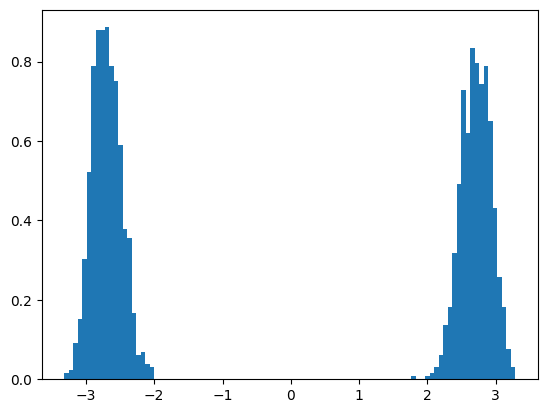

In [30]:
_ = plt.hist(samples.flatten(), bins=100, density=True)

In [18]:
from jax._src.flatten_util import ravel_pytree
from jax._src import linear_util as lu

In [19]:
x = {"x": jnp.ones((100,1)), "y": jnp.ones((100,1))}
y = jnp.ones((100,1))*0.2

In [20]:
def f(x, y):
    return (x["x"] + x["y"]) * y

In [21]:
from jax._src.api_util import flatten_fun as flatten_fun_
from jax._src.api_util import flatten_fun_nokwargs as flatten_fun_nokwargs_
from jax._src.api_util import flatten_axes

In [22]:
def ravel_pytree_by_axis(tree, axis = -1):
    leaves, treedef = jax.tree_util.tree_flatten(tree)
    shapes = jax.tree_util.tree_map(lambda x: x.shape, leaves)
    # Check if all shapes are the same, except the specified axis can be different
    shape_without_axis = shapes[0][:axis] + shapes[0][axis+1:]
    assert all(tuple(shape[:axis] + shape[axis+1:]) == shape_without_axis for shape in shapes[1:]), "All dimensions must be the same except the specified axis"
    
    axis_sizes = jax.tree_util.tree_map(lambda x: x.shape[axis], leaves)

    def unravel_array(array):
        split = jnp.split(array, axis_sizes, axis=axis)
        return jax.tree_util.tree_unflatten(treedef, split)
        
    
    return jnp.concatenate(leaves, axis=axis), unravel_array

In [28]:
def ravel_first_arg(f, unravel):
  return ravel_first_arg_(lu.wrap_init(f), unravel).call_wrapped

def ravel_args(f, unravel):
  return ravel_args_(lu.wrap_init(f), unravel).call_wrapped

def flatten_args(f, in_tree):
  return flatten_args_(lu.wrap_init(f), in_tree).call_wrapped

def flatten_fun(f, in_tree):
  f_flat, out_tree = flatten_fun_(lu.wrap_init(f), in_tree)
  return f_flat.call_wrapped, out_tree
  

@lu.transformation
def ravel_first_arg_(unravel, y_flat, *args):
    y = unravel(y_flat)
    ans = yield (y,) + args, {}
    ans_flat, _ = ravel_pytree(ans)
    yield ans_flat
   
@lu.transformation 
def ravel_args_(unravel, args_flat):
    args = unravel(args_flat)
    ans = yield args, {}
    ans_flat, _ = ravel_pytree(ans)
    yield ans_flat
    

@lu.transformation
def flatten_args_(in_tree, args):
    args = jax.tree_util.tree_unflatten(in_tree, tuple(args))
    ans = yield args, {}
    ans_flat, _ = jax.tree_util.tree_flatten(ans)
    yield ans_flat
  

In [29]:
flat_x, unravel = ravel_pytree(x)
f_flat = ravel_first_arg(f, unravel)
f_flat(flat_x, y)

Array([0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4,
       0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4,
       0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4,
       0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4,
       0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4,
       0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4,
       0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4,
       0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4], dtype=float32)

In [30]:
flat_x, unravel = ravel_pytree((x,y))
f_flat2 = ravel_args(f, unravel)

In [31]:
flat_x, in_tree = jax.tree_util.tree_flatten(x)
f_flat3, out_tree = flatten_fun(f, in_tree)

In [32]:
f_flat3(*flat_x)

TypeError: dict() argument after ** must be a mapping, not str

In [284]:
flat_args, intree = jax.tree_util.tree_flatten((x,y))
f_warp = lu.wrap_init(f)
f_flat, out_tree = flatten_fun_nokwargs_(f_warp, intree)
out = f_flat.call_wrapped(*flat_args)
output = jax.tree_unflatten(out_tree(), out)

/tmp/ipykernel_26526/2722155376.py:5: DeprecationWarning: jax.tree_unflatten is deprecated: use jax.tree_util.tree_unflatten.
  output = jax.tree_unflatten(out_tree(), out)


In [288]:
flatten_axes("test", in_tree, jax.tree_unflatten(in_tree, (0,0,0)))

/tmp/ipykernel_26526/158589325.py:1: DeprecationWarning: jax.tree_unflatten is deprecated: use jax.tree_util.tree_unflatten.
  flatten_axes("test", in_tree, jax.tree_unflatten(in_tree, (0,0,0)))


[0, 0, 0]